# Q1 Fixed-Basis Compact-Interpolated Lindblad-Safe Test

This notebook exercises the new fixed-basis compact-derived interpolation path
with Lindblad-safe decay reconstruction from per-target excited-subspace decay
kernels.

In [1]:
from __future__ import annotations

import importlib.util
import pathlib
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import cumulative_trapezoid, solve_ivp
from scipy.linalg import eigvals


def load_runtime_module():
    cwd = pathlib.Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        runtime_path = (
            candidate / "examples" / "effective hamiltonian" / "effective_hamiltonian_runtime.py"
        )
        if runtime_path.exists():
            spec = importlib.util.spec_from_file_location(
                "effective_hamiltonian_runtime", runtime_path
            )
            module = importlib.util.module_from_spec(spec)
            sys.modules[spec.name] = module
            spec.loader.exec_module(module)
            return module
    raise FileNotFoundError(
        "Could not locate examples/effective hamiltonian/effective_hamiltonian_runtime.py"
    )


plt.rcParams.update({"font.size": 14})

ehr = load_runtime_module()


In [2]:
TRANSITION = ehr.transitions.Q1_F1_1o2_F0
PATCH_POINTS_VCM = [0.0, 5.0, 7.0, 7.5, 8.0, 10.0, 20.0, 30.0, 40.0, 50.0]
MASTER_FIELD_VCM = 10.0
B_FIELD = (0.0, 0.0, 1e-5)
STATIC_FIELDS_VCM = [0.0, 7.0, 7.5, 8.0, 10.0, 20.0, 50.0]
RABI_RATE = 2.0 * np.pi * 1e6
DETUNING = 0.0

model = ehr.prepare_lindblad_safe_compact_interpolated_model(
    field_points=PATCH_POINTS_VCM,
    transition=TRANSITION,
    magnetic_field=B_FIELD,
    master_field=MASTER_FIELD_VCM,
)

print("n_effective_states:", model.n_effective_states)
print("ground_main_index_p:", model.ground_main_index_p)
print("field_points:", model.field_points.tolist())

n_effective_states: 15
ground_main_index_p: 2
field_points: [0.0, 5.0, 7.0, 7.5, 8.0, 10.0, 20.0, 30.0, 40.0, 50.0]


In [3]:
ACTIVE_INDICES = np.concatenate([model.ground_indices, model.excited_indices]).astype(np.int64)


def liouvillian_diagnostics(bundle):
    L = bundle.liouvillian_superoperator(rabi_rate=RABI_RATE, detuning=DETUNING)
    return float(np.max(np.real(eigvals(L)))), float(np.linalg.norm(L))


def bundle_target_kernels(bundle):
    return ehr._single_target_decay_kernels(
        np.asarray(bundle.c_array, dtype=np.complex128),
        np.asarray(model.excited_indices, dtype=np.int64),
        np.asarray(model.target_indices, dtype=np.int64),
    )


def block_norm(matrix, rows, cols):
    return float(np.linalg.norm(np.asarray(matrix, dtype=np.complex128)[np.ix_(rows, cols)]))


def static_operator_diagnostics(field_vcm):
    electric = (0.0, 0.0, float(field_vcm))
    _, compact_bundle = ehr._aligned_exact_compact_bundle_for_field(model, electric)
    interp_bundle = model.effective_bundle(electric, B_FIELD)

    h_int_active_err = float(
        np.linalg.norm(
            interp_bundle.h_internal[np.ix_(ACTIVE_INDICES, ACTIVE_INDICES)]
            - compact_bundle.h_internal[np.ix_(ACTIVE_INDICES, ACTIVE_INDICES)]
        )
        / max(
            np.linalg.norm(compact_bundle.h_internal[np.ix_(ACTIVE_INDICES, ACTIVE_INDICES)]),
            1.0,
        )
    )
    h_int_full_err = float(
        np.linalg.norm(interp_bundle.h_internal - compact_bundle.h_internal)
        / max(np.linalg.norm(compact_bundle.h_internal), 1.0)
    )
    h_opt_err = float(
        np.linalg.norm(interp_bundle.h_opt - compact_bundle.h_opt)
        / max(np.linalg.norm(compact_bundle.h_opt), 1.0)
    )
    h_det_err = float(
        np.linalg.norm(interp_bundle.h_det - compact_bundle.h_det)
        / max(np.linalg.norm(compact_bundle.h_det), 1.0)
    )

    interp_target = np.array(bundle_target_kernels(interp_bundle), dtype=np.complex128)
    compact_target = np.array(bundle_target_kernels(compact_bundle), dtype=np.complex128)
    n_ground = int(model.ground_indices.size)
    ground_kernel_err = float(
        np.linalg.norm(interp_target[:n_ground] - compact_target[:n_ground])
        / max(np.linalg.norm(compact_target[:n_ground]), 1.0)
    )
    sink_kernel_err = float(
        np.linalg.norm(interp_target[n_ground:] - compact_target[n_ground:])
        / max(np.linalg.norm(compact_target[n_ground:]), 1.0)
    )
    psd_mins = [
        float(np.min(np.linalg.eigvalsh(ehr._symmetrize(kernel)))) for kernel in interp_target
    ]
    max_real_liouvillian_eig, liouvillian_norm = liouvillian_diagnostics(interp_bundle)
    return {
        "field_vcm": float(field_vcm),
        "h_internal_active_rel_err": h_int_active_err,
        "h_internal_full_rel_err": h_int_full_err,
        "h_opt_rel_err": h_opt_err,
        "h_det_rel_err": h_det_err,
        "ground_kernel_rel_err": ground_kernel_err,
        "sink_kernel_rel_err": sink_kernel_err,
        "max_real_liouvillian_eig": max_real_liouvillian_eig,
        "liouvillian_norm": liouvillian_norm,
        "max_real_over_norm": max_real_liouvillian_eig / max(liouvillian_norm, 1.0),
        "min_kernel_eig": min(psd_mins) if psd_mins else None,
        "h_det_gg_interp_norm": block_norm(
            interp_bundle.h_det, model.ground_indices, model.ground_indices
        ),
        "h_det_gg_compact_norm": block_norm(
            compact_bundle.h_det, model.ground_indices, model.ground_indices
        ),
        "h_det_ee_interp_norm": block_norm(
            interp_bundle.h_det, model.excited_indices, model.excited_indices
        ),
        "h_det_ee_compact_norm": block_norm(
            compact_bundle.h_det, model.excited_indices, model.excited_indices
        ),
        "n_jump_ops": int(interp_bundle.c_array.shape[0]),
    }


static_diag = [static_operator_diagnostics(field) for field in STATIC_FIELDS_VCM]
static_diag


[{'field_vcm': 0.0,
  'h_internal_active_rel_err': 2.377642815251829e-15,
  'h_internal_full_rel_err': 2.377642815251829e-15,
  'h_opt_rel_err': 2.0054779265498454e-15,
  'h_det_rel_err': 1.5611432936735653e-15,
  'ground_kernel_rel_err': 2.461625803863549e-15,
  'sink_kernel_rel_err': 0.0,
  'max_real_liouvillian_eig': 4.400091711431742e-05,
  'liouvillian_norm': 928915782969.2312,
  'max_real_over_norm': 4.7368036931906536e-17,
  'min_kernel_eig': 0.0,
  'h_det_gg_interp_norm': 1.4142135623730956,
  'h_det_gg_compact_norm': 1.4142135623730956,
  'h_det_ee_interp_norm': 0.0,
  'h_det_ee_compact_norm': 0.0,
  'n_jump_ops': 8},
 {'field_vcm': 7.0,
  'h_internal_active_rel_err': 2.4982339553801395e-15,
  'h_internal_full_rel_err': 2.4982339553801395e-15,
  'h_opt_rel_err': 1.2801770599224538e-15,
  'h_det_rel_err': 1.9313891220435234e-15,
  'ground_kernel_rel_err': 3.139657656385269e-15,
  'sink_kernel_rel_err': 0.0,
  'max_real_liouvillian_eig': 4.8354280531690344e-05,
  'liouvillian_no

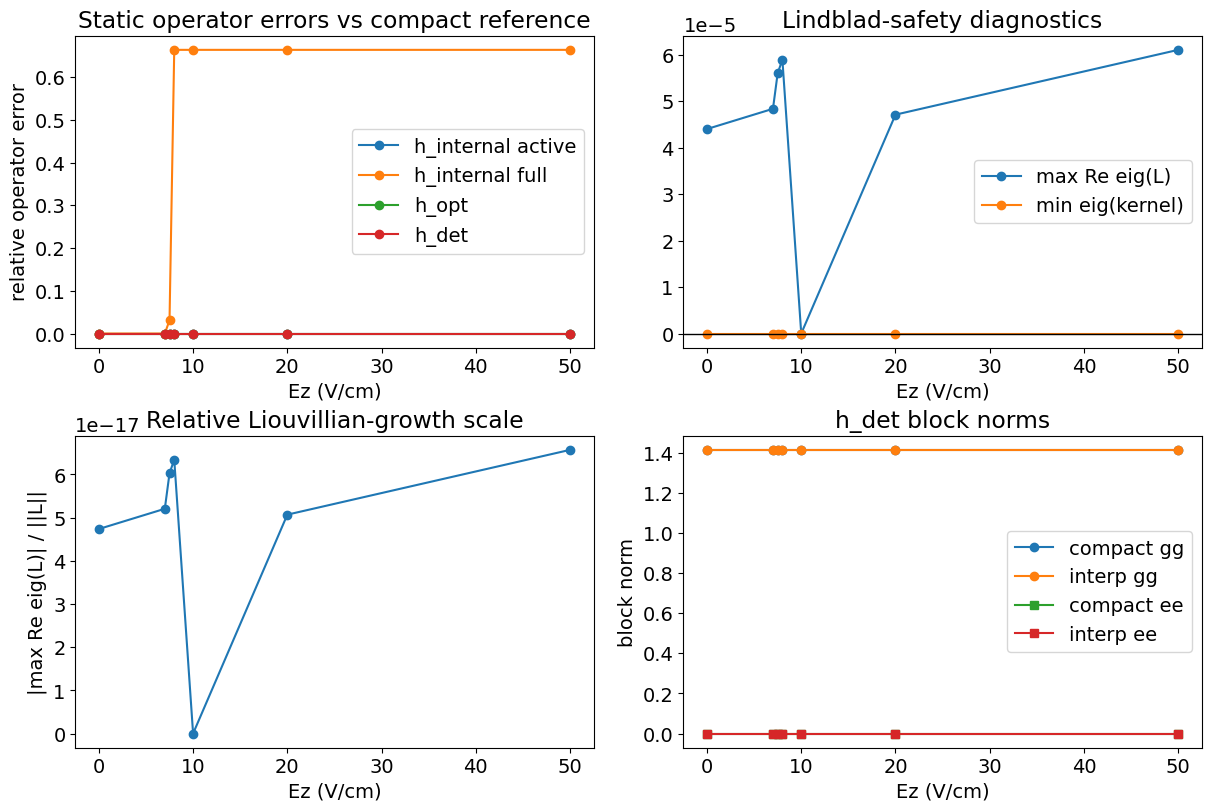

In [4]:
fields = np.array([row["field_vcm"] for row in static_diag], dtype=float)
h_int_active_err = np.array([row["h_internal_active_rel_err"] for row in static_diag], dtype=float)
h_int_full_err = np.array([row["h_internal_full_rel_err"] for row in static_diag], dtype=float)
h_opt_err = np.array([row["h_opt_rel_err"] for row in static_diag], dtype=float)
h_det_err = np.array([row["h_det_rel_err"] for row in static_diag], dtype=float)
max_real = np.array([row["max_real_liouvillian_eig"] for row in static_diag], dtype=float)
max_real_over_norm = np.array([row["max_real_over_norm"] for row in static_diag], dtype=float)
min_kernel = np.array(
    [row["min_kernel_eig"] if row["min_kernel_eig"] is not None else np.nan for row in static_diag],
    dtype=float,
)
h_det_gg_interp = np.array([row["h_det_gg_interp_norm"] for row in static_diag], dtype=float)
h_det_gg_compact = np.array([row["h_det_gg_compact_norm"] for row in static_diag], dtype=float)
h_det_ee_interp = np.array([row["h_det_ee_interp_norm"] for row in static_diag], dtype=float)
h_det_ee_compact = np.array([row["h_det_ee_compact_norm"] for row in static_diag], dtype=float)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes[0, 0].plot(fields, h_int_active_err, marker="o", label="h_internal active")
axes[0, 0].plot(fields, h_int_full_err, marker="o", label="h_internal full")
axes[0, 0].plot(fields, h_opt_err, marker="o", label="h_opt")
axes[0, 0].plot(fields, h_det_err, marker="o", label="h_det")
axes[0, 0].set_xlabel("Ez (V/cm)")
axes[0, 0].set_ylabel("relative operator error")
axes[0, 0].set_title("Static operator errors vs compact reference")
axes[0, 0].legend()

axes[0, 1].plot(fields, max_real, marker="o", label="max Re eig(L)")
axes[0, 1].plot(fields, min_kernel, marker="o", label="min eig(kernel)")
axes[0, 1].axhline(0.0, color="k", linewidth=1)
axes[0, 1].set_xlabel("Ez (V/cm)")
axes[0, 1].set_title("Lindblad-safety diagnostics")
axes[0, 1].legend()

axes[1, 0].plot(fields, np.abs(max_real_over_norm), marker="o")
axes[1, 0].set_xlabel("Ez (V/cm)")
axes[1, 0].set_ylabel("|max Re eig(L)| / ||L||")
axes[1, 0].set_title("Relative Liouvillian-growth scale")

axes[1, 1].plot(fields, h_det_gg_compact, marker="o", label="compact gg")
axes[1, 1].plot(fields, h_det_gg_interp, marker="o", label="interp gg")
axes[1, 1].plot(fields, h_det_ee_compact, marker="s", label="compact ee")
axes[1, 1].plot(fields, h_det_ee_interp, marker="s", label="interp ee")
axes[1, 1].set_xlabel("Ez (V/cm)")
axes[1, 1].set_ylabel("block norm")
axes[1, 1].set_title("h_det block norms")
axes[1, 1].legend()
plt.show()


In [5]:
STATIC_TEST_FIELDS = [0.0, 7.0, 7.5, 8.0, 10.0]
STATIC_T_FINAL = 2e-6
STATIC_T_EVAL = np.linspace(0.0, STATIC_T_FINAL, 251)

static_results = []
for field in STATIC_TEST_FIELDS:
    electric = (0.0, 0.0, float(field))
    _, compact_bundle = ehr._aligned_exact_compact_bundle_for_field(model, electric)
    interp_bundle = model.effective_bundle(electric, B_FIELD)
    compact_solution = ehr.solve_static_density_matrix_bundle(
        compact_bundle,
        rho0=ehr.default_effective_density_matrix(model),
        t_span=(0.0, STATIC_T_FINAL),
        rabi_rate=RABI_RATE,
        detuning=DETUNING,
        t_eval=STATIC_T_EVAL,
        method="RK45",
    )
    interp_solution = ehr.solve_static_lindblad_safe_compact_interpolated_model(
        model,
        electric_field=electric,
        magnetic_field=B_FIELD,
        rabi_rate=RABI_RATE,
        detuning=DETUNING,
        t_span=(0.0, STATIC_T_FINAL),
        t_eval=STATIC_T_EVAL,
        method="RK45",
    )
    rho_compact = ehr.solution_to_density_matrices(
        compact_solution, compact_bundle.h_internal.shape[0]
    )
    rho_interp = ehr.solution_to_density_matrices(interp_solution, model.n_effective_states)
    photons_compact = float(
        np.trapezoid(
            ehr.scattering_signal(rho_compact, compact_bundle.jump_rate_operator()),
            x=STATIC_T_EVAL,
        )
    )
    photons_interp = float(
        np.trapezoid(
            ehr.scattering_signal(rho_interp, interp_bundle.jump_rate_operator()),
            x=STATIC_T_EVAL,
        )
    )
    static_results.append(
        {
            "field_vcm": field,
            "photons_compact": photons_compact,
            "photons_interp": photons_interp,
            "rel_err": (photons_interp - photons_compact) / max(abs(photons_compact), 1.0),
        }
    )

static_results


KeyboardInterrupt: 

In [12]:
OSC_FREQUENCY_HZ = 100e3
OSC_OMEGA = 2.0 * np.pi * OSC_FREQUENCY_HZ
OSC_AMPLITUDE_VCM = 25.0
OSC_PERIOD = 1.0 / OSC_FREQUENCY_HZ
OSC_T_EVAL = np.linspace(0.0, OSC_PERIOD, 401)


def oscillating_field(t):
    ez = OSC_AMPLITUDE_VCM * (1.0 - np.cos(OSC_OMEGA * t))
    return (0.0, 0.0, ez)


endpoint_jump_rates = [
    model.effective_bundle((0.0, 0.0, float(field)), B_FIELD).jump_rate_operator()
    for field in model.field_points.tolist()
]


def interpolated_jump_rate_operator(field_vcm):
    lower, upper, weight = model._interpolation_indices(float(field_vcm))
    if lower == upper:
        return np.asarray(endpoint_jump_rates[lower], dtype=np.complex128)
    return np.asarray(
        endpoint_jump_rates[lower]
        + weight * (endpoint_jump_rates[upper] - endpoint_jump_rates[lower]),
        dtype=np.complex128,
    )


osc_solution = ehr.solve_lindblad_safe_compact_interpolated_model(
    model,
    electric_field=oscillating_field,
    magnetic_field=B_FIELD,
    rabi_rate=RABI_RATE / 100,
    detuning=DETUNING,
    t_span=(0.0, OSC_PERIOD),
    t_eval=OSC_T_EVAL,
    method="BDF",
)

rho_osc = ehr.solution_to_density_matrices(osc_solution, model.n_effective_states)
osc_rates = np.array(
    [
        np.real(np.trace(rho @ interpolated_jump_rate_operator(oscillating_field(t)[2])))
        for rho, t in zip(rho_osc, OSC_T_EVAL)
    ],
    dtype=float,
)
osc_photons = float(np.trapezoid(osc_rates, x=OSC_T_EVAL))
{"osc_photons": osc_photons, "nfev": int(osc_solution.nfev)}


{'osc_photons': 0.017860854343312114, 'nfev': 142}

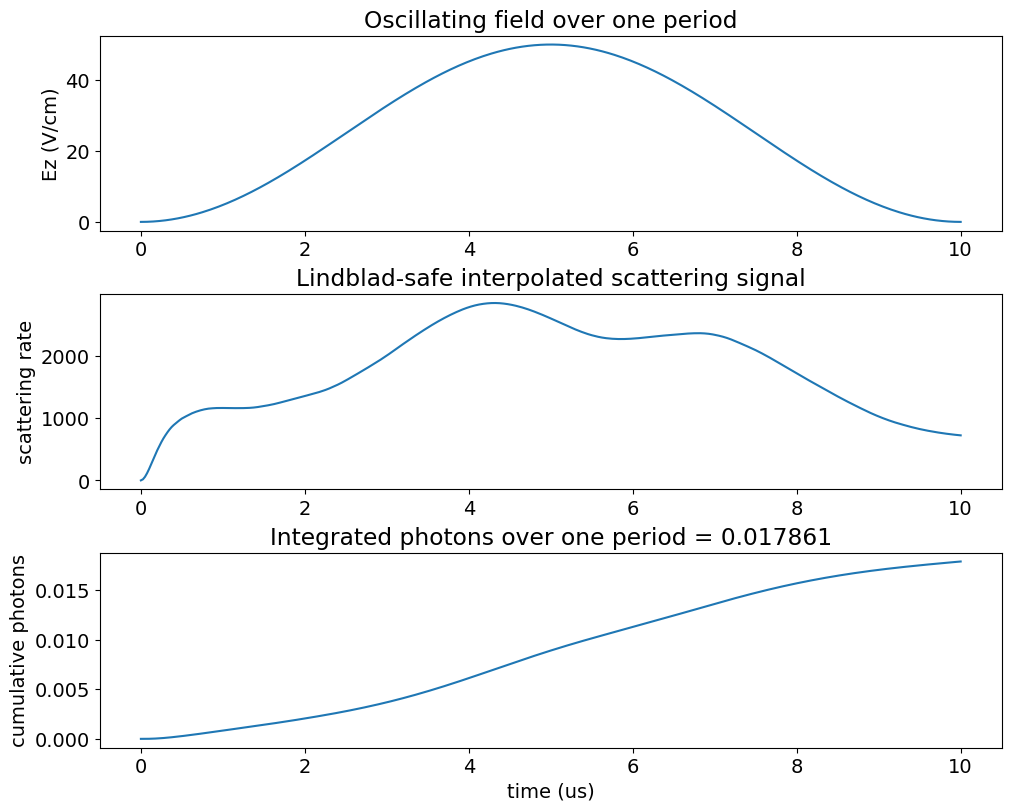

In [13]:
ez_t = np.array([oscillating_field(t)[2] for t in OSC_T_EVAL], dtype=float)
cum_photons = np.concatenate([[0.0], cumulative_trapezoid(osc_rates, x=OSC_T_EVAL)])

fig, axes = plt.subplots(3, 1, figsize=(10, 8), constrained_layout=True)
axes[0].plot(1e6 * OSC_T_EVAL, ez_t)
axes[0].set_ylabel("Ez (V/cm)")
axes[0].set_title("Oscillating field over one period")

axes[1].plot(1e6 * OSC_T_EVAL, osc_rates)
axes[1].set_ylabel("scattering rate")
axes[1].set_title("Lindblad-safe interpolated scattering signal")

axes[2].plot(1e6 * OSC_T_EVAL, cum_photons)
axes[2].set_xlabel("time (us)")
axes[2].set_ylabel("cumulative photons")
axes[2].set_title(f"Integrated photons over one period = {osc_photons:.6f}")
plt.show()


In [ ]:
def solve_lindblad_safe_compact_interpolated_model_real(
    model,
    *,
    electric_field,
    magnetic_field,
    rho0,
    t_span,
    rabi_rate,
    detuning,
    t_eval,
    method,
):
    rho0 = np.asarray(rho0, dtype=np.complex128)
    n_states = rho0.shape[0]
    n_vec = n_states * n_states

    fields = np.asarray(model.field_points, dtype=np.float64)
    endpoint_bundles = tuple(
        model.effective_bundle((0.0, 0.0, float(field_z)), model.reference_magnetic_field)
        for field_z in fields.tolist()
    )
    h_internal_superops = tuple(
        ehr._hamiltonian_superoperator(np.asarray(bundle.h_internal, dtype=np.complex128))
        for bundle in endpoint_bundles
    )
    h_opt_superops = tuple(
        ehr._hamiltonian_superoperator(np.asarray(bundle.h_opt, dtype=np.complex128))
        for bundle in endpoint_bundles
    )
    h_det_superops = tuple(
        ehr._hamiltonian_superoperator(np.asarray(bundle.h_det, dtype=np.complex128))
        for bundle in endpoint_bundles
    )
    dissipator_superops = tuple(
        np.asarray(bundle.dissipator_superoperator(), dtype=np.complex128)
        for bundle in endpoint_bundles
    )

    def interval_differences(values):
        return tuple(values[i + 1] - values[i] for i in range(len(values) - 1))

    dh_internal_superops = interval_differences(h_internal_superops)
    dh_opt_superops = interval_differences(h_opt_superops)
    dh_det_superops = interval_differences(h_det_superops)
    ddissipator_superops = interval_differences(dissipator_superops)

    def complex_liouvillian(t):
        electric = ehr._as_field_vector(ehr._parameter_at_time(electric_field, float(t)))
        lower, upper, weight = model._interpolation_indices(float(electric[2]))

        if lower == upper:
            h_int_super = h_internal_superops[lower]
            h_opt_super = h_opt_superops[lower]
            h_det_super = h_det_superops[lower]
            dissipator_super = dissipator_superops[lower]
        else:
            h_int_super = h_internal_superops[lower] + weight * dh_internal_superops[lower]
            h_opt_super = h_opt_superops[lower] + weight * dh_opt_superops[lower]
            h_det_super = h_det_superops[lower] + weight * dh_det_superops[lower]
            dissipator_super = dissipator_superops[lower] + weight * ddissipator_superops[lower]

        return (
            h_int_super
            + 0.5 * complex(ehr._parameter_at_time(rabi_rate, float(t))) * h_opt_super
            + float(ehr._parameter_at_time(detuning, float(t))) * h_det_super
            + dissipator_super
        )

    def real_block_matrix(L):
        return np.block(
            [
                [np.real(L), -np.imag(L)],
                [np.imag(L), np.real(L)],
            ]
        )

    y0_complex = rho0.reshape(-1)
    y0_real = np.concatenate([np.real(y0_complex), np.imag(y0_complex)])

    def rhs(t, y):
        return real_block_matrix(complex_liouvillian(t)) @ y

    def jac(t, y):
        return real_block_matrix(complex_liouvillian(t))

    sol = solve_ivp(
        rhs,
        t_span=t_span,
        y0=y0_real,
        t_eval=t_eval,
        method=method,
        jac=jac if method in ("BDF", "Radau") else None,
    )

    y_complex = sol.y[:n_vec] + 1j * sol.y[n_vec:]
    rho_t = np.moveaxis(y_complex.reshape(n_states, n_states, -1), -1, 0)
    return sol, rho_t


## Solver Method Benchmark

This section compares one-period oscillating-field runs using different `solve_ivp` methods on the same Lindblad-safe compact-interpolated model.


In [ ]:
BENCHMARK_METHODS = ["BDF", "Radau"]
solver_benchmarks = []
solver_traces = {}

rho0 = ehr.default_effective_density_matrix(model)

for method_name in BENCHMARK_METHODS:
    start = time.perf_counter()

    if method_name == "RK45":
        solution = ehr.solve_lindblad_safe_compact_interpolated_model(
            model,
            electric_field=oscillating_field,
            magnetic_field=B_FIELD,
            rho0=rho0,
            rabi_rate=RABI_RATE,
            detuning=DETUNING,
            t_span=(0.0, OSC_PERIOD),
            t_eval=OSC_T_EVAL,
            method=method_name,
        )
        rho_t = ehr.solution_to_density_matrices(solution, model.n_effective_states)
    else:
        solution, rho_t = solve_lindblad_safe_compact_interpolated_model_real(
            model,
            electric_field=oscillating_field,
            magnetic_field=B_FIELD,
            rho0=rho0,
            rabi_rate=RABI_RATE,
            detuning=DETUNING,
            t_span=(0.0, OSC_PERIOD),
            t_eval=OSC_T_EVAL,
            method=method_name,
        )

    elapsed_s = float(time.perf_counter() - start)
    rates_t = np.array(
        [
            np.real(np.trace(rho @ interpolated_jump_rate_operator(oscillating_field(t)[2])))
            for rho, t in zip(rho_t, OSC_T_EVAL)
        ],
        dtype=float,
    )
    photons_t = float(np.trapezoid(rates_t, x=OSC_T_EVAL))
    solver_traces[method_name] = {
        "rho": rho_t,
        "rates": rates_t,
        "cum_photons": np.concatenate([[0.0], cumulative_trapezoid(rates_t, x=OSC_T_EVAL)]),
    }
    solver_benchmarks.append(
        {
            "method": method_name,
            "elapsed_s": elapsed_s,
            "nfev": int(solution.nfev),
            "njev": None if getattr(solution, "njev", None) is None else int(solution.njev),
            "nlu": None if getattr(solution, "nlu", None) is None else int(solution.nlu),
            "status": int(solution.status),
            "success": bool(solution.success),
            "photons": photons_t,
        }
    )

solver_benchmarks


[{'method': 'RK45',
  'elapsed_s': 3283.202760200016,
  'nfev': 5278160,
  'njev': 0,
  'nlu': 0,
  'status': 0,
  'success': True,
  'photons': 1.1000686497657544},
 {'method': 'BDF',
  'elapsed_s': 3.273503799980972,
  'nfev': 332,
  'njev': 5,
  'nlu': 36,
  'status': 0,
  'success': True,
  'photons': 1.0997829178270102},
 {'method': 'Radau',
  'elapsed_s': 7.476296500011813,
  'nfev': 395,
  'njev': 11,
  'nlu': 64,
  'status': 0,
  'success': True,
  'photons': 1.1001297154036227}]

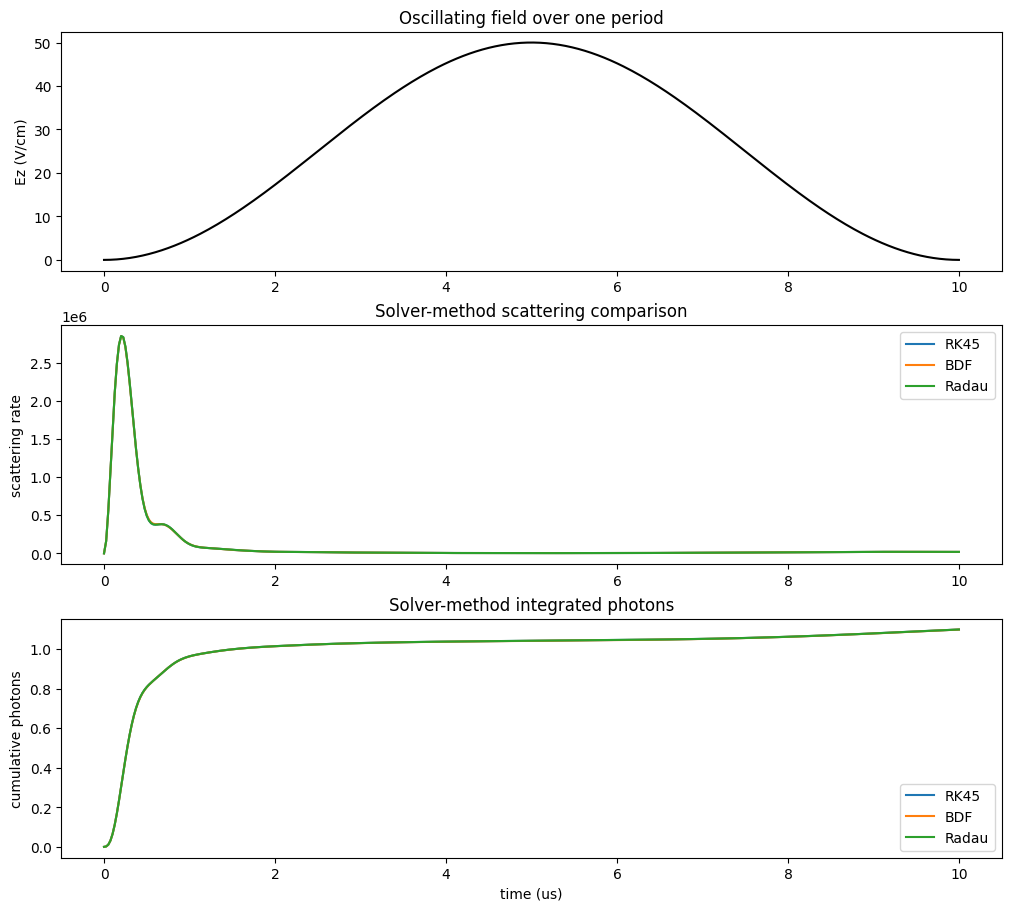

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), constrained_layout=True)
axes[0].plot(1e6 * OSC_T_EVAL, ez_t, color="k", linewidth=1.5)
axes[0].set_ylabel("Ez (V/cm)")
axes[0].set_title("Oscillating field over one period")

for method_name in BENCHMARK_METHODS:
    axes[1].plot(1e6 * OSC_T_EVAL, solver_traces[method_name]["rates"], label=method_name)
    axes[2].plot(1e6 * OSC_T_EVAL, solver_traces[method_name]["cum_photons"], label=method_name)

axes[1].set_ylabel("scattering rate")
axes[1].set_title("Solver-method scattering comparison")
axes[1].legend()

axes[2].set_xlabel("time (us)")
axes[2].set_ylabel("cumulative photons")
axes[2].set_title("Solver-method integrated photons")
axes[2].legend()
plt.show()
